In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import linregress
import zipfile
import xmltodict
from collections import defaultdict
import matplotlib.pyplot as plt


# TODO: Handle (how?) composite sampling. For now, average all data for one PK timepoint on the same day within the same dose group. Make sure you don't composite male with female.
# TODO: Future improvement - for composite sampling, calculate every composite combination so you can calculate error and significant differences.
# TODO: Put data cleaning and input handling into separate functions specific to a provider based on 'company' from app metadata or wherever. Current code handles WuXi output, will probably also need Pharmaron.


header_row_flag = 'Day Nominal'
sheet_name = 'Summary'

col_lut = {'day nominal': 'day',
           'subject group': 'group',
           'subject alias': 'animal_no',
           'gender': 'sex',
           'custom id': 'sample_no',
           'hour nominal': 'hour',
           'treatment id': 'day_dose',
           'mg/kg/day': 'dose_mpk',
           'final concentration': 'conc'}


def calculate_cmax(df):
    """
    Calculates Cmax (maximum concentration) and the time at which it occurs (Tmax).
    :param df: Pandas dataframe with data from one animal on one day.
    :return: Cmax, Tmax
    """
    cmax = df['conc'].max()
    tmax = df.loc[df['conc'].idxmax(), 'hour']

    return cmax, tmax


def auc_linear(df):
    """
    Calculates AUC using the linear trapezoidal rule.
    :param df: pandas DataFrame with plasma concentrations from one animal on one day, sorted by hour.
    :return: AUC calculated by the linear trapezoidal rule.
    """
    time = [float(x) for x in df['hour'].tolist()]
    conc = [float(x) for x in df['conc'].tolist()]
    auc = 0.0
    for i in range(len(time) - 1):
        auc += ((conc[i] + conc[i + 1]) / 2) * (time[i + 1] - time[i])

    return auc


def auc_log_linear(df):
    """
    Calculates AUC using the log-linear trapezoidal rule.
    Applies linear trapezoidal when conc[i+1] >= conc[i]. IOW, uses linear trapezoidal rule when plasma concentration is increasing, log interpolation when plasma concentration is decreasing.
    :param df: pandas DataFrame with plasma concentrations from one animal on one day, sorted by hour.
    :return: AUC calculated by the linear log-linear trapezoidal rule.
    """
    time = [float(x) for x in df['hour'].tolist()]
    conc = [float(x) for x in df['conc'].tolist()]
    auc = 0.0

    for i in range(len(time) - 1):
        delta_t = time[i + 1] - time[i]

        if 0 < conc[i + 1] < conc[i] and conc[i] > 0:
            # Log-linear interpolation for elimination phase
            auc += ((conc[i] - conc[i + 1]) / np.log(conc[i] / conc[i + 1])) * delta_t

        else:
            # Linear interpolation for absorption phase or when concentrations are equal
            auc += ((conc[i] + conc[i + 1]) / 2) * delta_t

    return round(auc.item(), 1)


def calculate_half_life(df, time_col='hour', conc_col='conc'):
    # Check if necessary columns are present
    if time_col not in df.columns or conc_col not in df.columns:
        return None

    # Drop any rows with NaN values
    clean_df = df[[time_col, conc_col]].dropna()

    # Ensure data has enough points for calculation
    if len(clean_df) < 2:
        return None

    # Log-transform the concentration values (first-order elimination assumption)
    clean_df['log_conc'] = np.log(clean_df[conc_col])

    # Perform linear regression on time vs log(concentration)
    slope, intercept, r_value, p_value, std_err = linregress(
        clean_df[time_col], clean_df['log_conc']
    )

    # Ensure slope is negative (drug elimination) and meaningful regression fit
    if slope >= 0 or r_value**2 < 0.8:  # R-squared threshold for good fit
        return None

    # Calculate half-life using the slope
    half_life = -np.log(2) / slope

    return half_life


def crop_dataframe(df):
    """
    Crops the dataframe to the actual data, omitting extraneous info.
    :param df: Dataframe with extraneous info in the top rows.
    :return: Dataframe without extraneous info.
    """
    col_name = df.columns[0]
    header_row = df.index[df[col_name] == header_row_flag].tolist()[0]
    df1 = df.loc[header_row + 1:, :].reset_index(drop=True)
    df1.columns = df.iloc[header_row]

    return df1


def rename_columns(df):
    """
    Standardize column names.
    :param df: Dataframe with WuXi column names.
    :return: Dataframe with standard column names.
    """
    new_col_names = list()

    for col_name in df:
        initial = len(new_col_names)

        for flag, new_name in col_lut.items():
            if flag in col_name.lower():
                new_col_names.append(new_name)
                break

        if len(new_col_names) == initial:           # if old column name not found in col_lut
            new_col_names.append(col_name)

    df.columns = new_col_names

    return df


def split_dataframe(df):
    df['conc'] = df['conc'].astype(float)
    df['hour'] = df['hour'].astype(float)
    animal_day_df_list = list()
    sex_animal_day_df_list = list()

    day_df_list = split_dataframe_by(df, 'day')

    for dfa in day_df_list:
        animal_day_df_list.extend(split_dataframe_by(dfa, 'animal_no'))

    for dfb in animal_day_df_list:
        sex_animal_day_df_list.extend(split_dataframe_by(dfb, 'sex'))

    return sex_animal_day_df_list


def split_dataframe_by(df, col_name):
    """
    Splits dataframe into a list of dataframes, each comprising all data from that study day. use prior to splitting each dataframe by unique values in column 'col_name'.
    :param df: Dataframe with multiple values in column 'col_name'.
    :param col_name: Column name of dataframe.
    :return: List of dataframes, one for each unique value in column 'col_name'.
    """

    unique_vals = df[col_name].unique().tolist()
    df_list = [df[df[col_name] == val].sort_values(by='hour') for val in unique_vals]

    return df_list


def calculate_df_pk_parameters(df_list):
    """
    Calculates PK parameters for a list of dataframes (df_list).
    :param df_list: List of dataframes containing drug concentrations in plasma, organ, etc.
    :return: Dataframe of PK parameters for each animal.
    """

    pk_dict = {
        'animal_ids':    df1['animal_no'].unique().tolist(),
        'cmax':          list(),
        'tmax':          list(),
        'lin_auc':       list(),
        'log_lin_auc':   list(),
        'sex':           list(),
        'day':           list(),
        't-half':        list(),
        }

    for df in df_list:
        c, t = calculate_cmax(df)
        pk_dict['cmax'].append(c)
        pk_dict['tmax'].append(t)

        a1, a2 = auc_linear(df), auc_log_linear(df)
        pk_dict['lin_auc'].append(a1)
        pk_dict['log_lin_auc'].append(a2)

        pk_dict['sex'].append(df['sex'].unique().tolist()[0])
        pk_dict['day'].append(df['day'].unique().tolist()[0])

        pk_dict['t-half'].append(calculate_half_life(df))

    return pd.DataFrame(pk_dict)


def get_unique_supersets(df_list, col_name='hour'):
    # Convert lists to sets for easier comparison
    lists = [df[col_name].unique().tolist() for df in df_list]

    for i, lst in enumerate(lists):
        lists[i] = [int(x) for x in lst]

    sets = [set(lst) for lst in lists]

    # Remove duplicates by converting to a set of frozensets
    unique_sets = list(map(set, {frozenset(s) for s in sets}))

    # Keep only sets that are not a subset of another set
    result = []
    for s in unique_sets:
        if not any(s < other for other in unique_sets if s != other):
            result.append(list(s))  # Convert back to list for final output

    return result


def group_dataframes(df_list):
    """
    Groups a list of DataFrames based on the first values in the 'day', 'group', and 'sex' columns.
    :param: (list of pd.DataFrame): List of dataframes to be grouped.
    :return: list of lists: Grouped dataframes based on matching first values in 'day', 'group', and 'sex' columns.
    """
    grouped = defaultdict(list)

    for df in df_list:
        if not df.empty and {'day', 'group', 'sex'}.issubset(df.columns):
            key = (df.iloc[0]['day'], df.iloc[0]['group'], df.iloc[0]['sex'])
            grouped[key].append(df)

    return list(grouped.values())


def extract_company_name_from_excel(file_path):
    with zipfile.ZipFile(file_path, 'r') as z:
        with z.open("docProps/app.xml") as f:
            content1 = f.read().decode(errors="ignore")
            content2 = xmltodict.parse(content1)
        return content2["Properties"]["Company"]


def validate_input(df):
    try:
        assert len(get_unique_supersets(df)) == 1
    except AssertionError:
        print('Composite sampling is not yet supported.')
        return False
    return True


def combine_concentration_data(df_list):
    """
    Combines the 'conc' column from each DataFrame in df_list into a final DataFrame.

    Parameters:
    df_list (list of pd.DataFrame): List of DataFrames containing 'hour', 'conc', and 'animal_no' columns.

    Returns:
    pd.DataFrame: A combined DataFrame with 'hour' as index and 'conc' columns labeled by the first 'animal_no' value.
    """
    combined_df = pd.DataFrame()

    for df in df_list:
        if 'hour' not in df or 'conc' not in df or 'animal_no' not in df:
            raise ValueError("Each DataFrame must contain 'hour', 'conc', and 'animal_no' columns.")

        animal_label = df['animal_no'].iloc[0]  # Get the first value of 'animal_no' column
        temp_df = df[['hour', 'conc']].copy()  # Select relevant columns
        temp_df = temp_df.rename(columns={'conc': animal_label})  # Rename 'conc' column
        temp_df.set_index('hour', inplace=True)  # Set 'hour' as index

        if combined_df.empty:
            combined_df = temp_df
        else:
            combined_df = combined_df.join(temp_df, how='outer')  # Merge on 'hour'

    return combined_df


def plot_concentration_profiles(df_list):
    """
    Plots multiple concentration profiles on a single graph and
    displays the average profile with standard deviation as a separate graph.

    Parameters:
    dataframes (list of pd.DataFrame): List of DataFrames, each containing 'hour' and 'conc' columns.
    """

    plt.figure(figsize=(10, 5))

    # Plot each dataset on the same graph
    for df in df_list:
        plt.plot(df['hour'], df['conc'], alpha=0.5, label='_nolegend_')  # Hide individual legends for clarity

    plt.xlabel("Time (h)")
    plt.ylabel("Plasma Concentration (ng/mL)")
    plt.title("Individual Plasma Concentration Profiles")
    plt.rcParams['figure.facecolor'] = 'white'  # this isn't doing anything.
    plt.grid(True)
    plt.show()

    # Aggregate data for mean and standard deviation calculation
    # Assume all dataframes have the same time points
    all_hours = df_list[0]['hour'].values

    # for df in dataframes:
    #     print(df)
    # print([df['conc'].values for df in dataframes])

    conc_values = np.array([df['conc'].values for df in df_list])

    mean_conc = np.mean(conc_values, axis=0)
    std_conc = np.std(conc_values, axis=0)

    # Second plot: Mean ± Standard Deviation
    plt.figure(figsize=(10, 5))
    plt.plot(all_hours, mean_conc, label="Mean Concentration", color='blue')
    plt.fill_between(all_hours, mean_conc - std_conc, mean_conc + std_conc, color='blue', alpha=0.2, label="±1 SD")

    plt.xlabel("Time (h)")
    plt.ylabel("Plasma Concentration (ng/mL)")
    plt.title("Mean Plasma Concentration with Standard Deviation")
    plt.legend()
    plt.grid(True)
    plt.show()


def save_output(df):
    pass

In [2]:
source_path = Path("C:\\Users\\mlalonde\\OneDrive - Kymera Therapeutics\\Desktop\\IRF5 Project\\In Vivo Work\\Primate Studies\\Non-GLP CV study in NHPs\\Report 2_KYMERA-8543690 (D8)_D-1893_20250221.xlsx")
df0 = pd.read_excel(source_path, sheet_name=sheet_name)
source_company = extract_company_name_from_excel(source_path)
df0.head()

,WuXi Study Number:,KYMERA-8543690,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,Client Study Number:,8543690 (D8),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Testing Facility:,"WuXi AppTec Laboratory Testing Division, 6 Ced...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Analytes:,D-1893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Analyst:,STZ,NaN,Date: 2/20/2025,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df1 = crop_dataframe(df0)
df1.head()

13,Day Nominal,Subject Group,Subject Alias,Gender,Custom ID,Hour Nominal,Treatment ID,Dose\n(mg/kg/day),D-1893 Final Concentration (ng/mL)
0,8,2,P0101,Male,572282000001,0,2_20,20,605
1,8,2,P0102,Male,572282000015,0,2_20,20,300
2,8,2,P0103,Male,572282000029,0,2_20,20,298
3,8,2,P0101,Male,572282000002,1,2_20,20,646
4,8,2,P0102,Male,572282000016,1,2_20,20,361


In [4]:
df1 = rename_columns(df1)
# inputs_are_valid = validate_input(df1)      # This is not yet driving a decision.
df1.head()

,day,group,animal_no,sex,sample_no,hour,day_dose,dose_mpk,conc
0,8,2,P0101,Male,572282000001,0,2_20,20,605
1,8,2,P0102,Male,572282000015,0,2_20,20,300
2,8,2,P0103,Male,572282000029,0,2_20,20,298
3,8,2,P0101,Male,572282000002,1,2_20,20,646
4,8,2,P0102,Male,572282000016,1,2_20,20,361


In [5]:
df_list_1 = split_dataframe(df1)
print(df_list_1[7])

   day group animal_no   sex     sample_no  hour day_dose dose_mpk    conc
42   8     4     P0302  Male  572282000099   0.0    4_100      100   989.0
45   8     4     P0302  Male  572282000100   1.0    4_100      100  1040.0
48   8     4     P0302  Male  572282000101   2.0    4_100      100  1090.0
51   8     4     P0302  Male  572282000102   4.0    4_100      100  1360.0
54   8     4     P0302  Male  572282000103   8.0    4_100      100  1360.0
57   8     4     P0302  Male  572282000104  12.0    4_100      100   978.0
60   8     4     P0302  Male  572282000105  24.0    4_100      100   947.0


In [6]:
validate_input(df_list_1)
df2 = calculate_df_pk_parameters(df_list_1)
df2.head(10)

,animal_ids,cmax,tmax,lin_auc,log_lin_auc,sex,day,t-half
0,P0101,934.0,4.0,15758.5,15712.3,Male,8,None
1,P0102,511.0,4.0,8769.0,8677.0,Male,8,None
2,P0103,697.0,4.0,10764.5,10584.3,Male,8,None
3,P0201,2020.0,4.0,37585.0,37511.1,Male,8,None
4,P0202,1490.0,8.0,26645.5,26523.0,Male,8,None
5,P0203,1600.0,4.0,32585.0,32495.0,Male,8,None
6,P0301,1640.0,8.0,30280.0,30206.5,Male,8,None
7,P0302,1360.0,4.0,26195.5,26152.6,Male,8,None
8,P0303,1240.0,8.0,22388.0,22245.8,Male,8,None


In [7]:
df_list_2 = group_dataframes(df_list_1)
#print([len(sublist) for sublist in df_list_2])
for df in df_list_2[1]:
    print(df)

   day group animal_no   sex     sample_no  hour day_dose dose_mpk    conc
22   8     3     P0202  Male  572282000057   0.0     3_60       60  1460.0
25   8     3     P0202  Male  572282000058   1.0     3_60       60  1570.0
27   8     3     P0202  Male  572282000059   2.0     3_60       60  1710.0
30   8     3     P0202  Male  572282000060   4.0     3_60       60  2020.0
33   8     3     P0202  Male  572282000061   8.0     3_60       60  1770.0
36   8     3     P0202  Male  572282000062  12.0     3_60       60  1510.0
39   8     3     P0202  Male  572282000063  24.0     3_60       60  1250.0
   day group animal_no   sex     sample_no  hour day_dose dose_mpk    conc
23   8     3     P0203  Male  572282000071   0.0     3_60       60   655.0
26   8     3     P0203  Male  572282000072   1.0     3_60       60   817.0
28   8     3     P0203  Male  572282000073   2.0     3_60       60  1070.0
31   8     3     P0203  Male  572282000074   4.0     3_60       60  1220.0
34   8     3     P0203  M

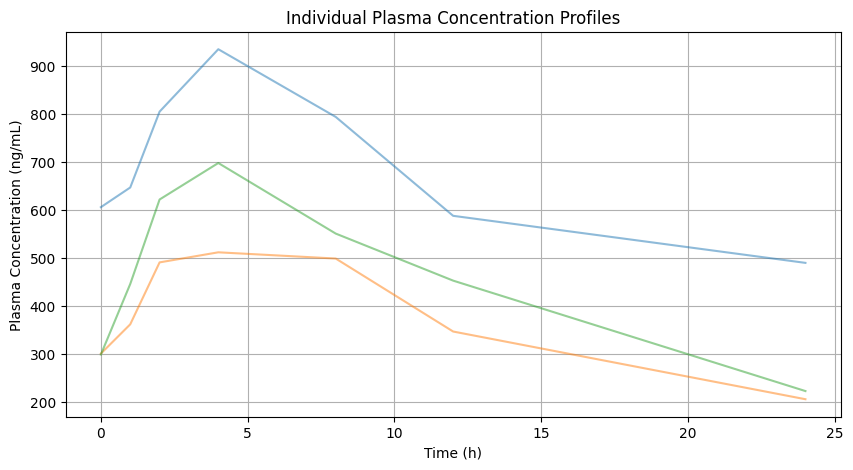

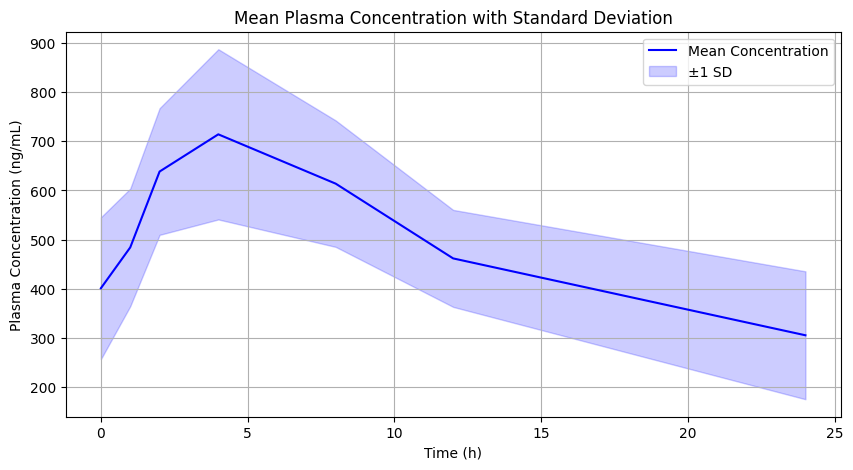

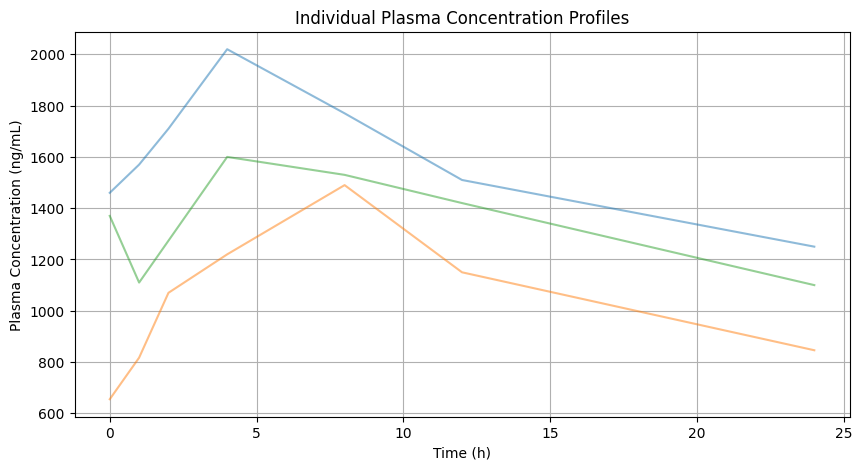

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

In [8]:
for df_list in df_list_2:
    plot_concentration_profiles(df_list)